# Exploratory Data Analysis (EDA) and Text Preprocessing

This notebook demonstrates how to perform **Exploratory Data Analysis (EDA) and text preprocessing** using a real text dataset.

We will use the **20 Newsgroups** dataset from `scikit-learn`. It contains text documents from different discussion topics, so it is useful for learning how to inspect, clean, tokenize, normalize, and analyze text before building NLP models.

## Learning objectives

By the end of this notebook, students should be able to:

1. Load a text dataset into a Pandas DataFrame.
2. Inspect basic dataset information such as number of samples, labels, and missing values.
3. Analyze text length using characters, words, and sentences.
4. Clean text by removing noisy texts and depulicates, lowercasing, removing punctuation, and handling extra spaces.
5. Tokenize text and remove stop words.
6. Apply stemming and lemmatization to normalize word forms.
7. Identify frequent words and compare vocabulary patterns across classes.
8. Visualize text data using charts and word clouds.
9. Detect rare words.




## 1. Install and import libraries

Most libraries are already available in Google Colab. The `wordcloud` package is usually installed, but the cell below installs it if needed.


In [ ]:
# Install required libraries if needed
!pip -q install wordcloud nltk

# Basic libraries
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset and stop words
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Visualization
from wordcloud import WordCloud

# Stemming and lemmatization
import nltk

from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download required NLTK resources

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

## 2. Load the dataset

We load four categories from the [20 Newsgroups dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html#gallery-examples) to keep the notebook fast and easy to understand.

You can change the categories if you want to explore more topics.

In [2]:
categories = [
    "sci.space",
    "rec.sport.baseball",
    "comp.graphics",
    "talk.politics.misc"
]

newsgroups = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

# Convert to DataFrame
df = pd.DataFrame({
    "text": newsgroups.data,
    "label_id": newsgroups.target
})

df["label"] = df["label_id"].map(lambda i: newsgroups.target_names[i])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2239, 3)


,text,label_id,label
0,I thought that was Sandy Koufax.,1,rec.sport.baseball
1,"\nAnd the religious right worships engines, sm...",3,talk.politics.misc
2,\nHow can a witness tell that someone in a bur...,3,talk.politics.misc
3,"\n\n\n\nYes, long before Star Trek. Before Ei...",2,sci.space
4,\n\nIt depends. If you can get your old veter...,1,rec.sport.baseball


## 3. Basic dataset inspection

First, we check the number of rows, columns, data types, missing values, and duplicate texts.


In [3]:
print("Rows and columns:", df.shape)
print("\nColumn information:")
df.info()

Rows and columns: (2239, 3)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      2239 non-null   object
 1   label_id  2239 non-null   int64 
 2   label     2239 non-null   object
dtypes: int64(1), object(2)
memory usage: 52.6+ KB


In [4]:
# Missing values
missing_values = df.isnull().sum()
missing_values

,0
text,0
label_id,0
label,0


In [5]:
# Empty or whitespace-only texts
empty_texts = df["text"].astype(str).str.strip().eq("").sum()
print("Number of empty texts:", empty_texts)

# Duplicate texts
duplicate_texts = df["text"].duplicated().sum()
print("Number of duplicate texts:", duplicate_texts)

Number of empty texts: 63
Number of duplicate texts: 56


## 4. Label distribution

If the dataset has labels, we should check whether the classes are balanced or imbalanced.


In [6]:
label_counts = df["label"].value_counts()
label_counts

,count
label,
rec.sport.baseball,597
sci.space,593
comp.graphics,584
talk.politics.misc,465


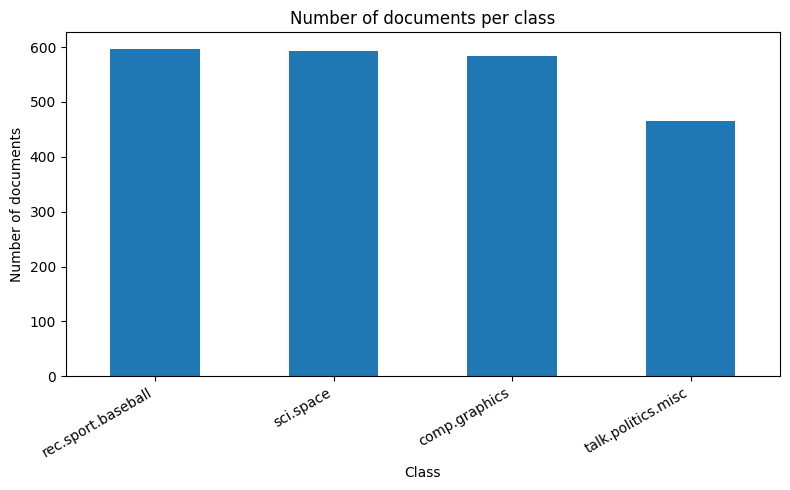

In [7]:
plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")
plt.title("Number of documents per class")
plt.xlabel("Class")
plt.ylabel("Number of documents")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Preview sample texts

It is important to manually read a few examples to understand the content, style, noise, and possible preprocessing needs.


In [8]:
for i in range(3):
    print("=" * 100)
    print("Label:", df.loc[i, "label"])
    print(df.loc[i, "text"][:1000])

Label: rec.sport.baseball
I thought that was Sandy Koufax.
Label: talk.politics.misc

And the religious right worships engines, smokestacks, landfills,
and hates people.

What does this name-calling have to do with anything you are claiming about
the truth of environmental disaster?  Nothing that I have read in this
thread, nor heard from anyone I have talked to, would suggest to me that 
people fit the definition you give of the religious left.  Come off it, Phil.
A prime motivation for protecting our environment is so that we, 
people, can continue to live in it healthily.  We just disagree on what
is necessary to maintaining a healthy environment FOR PEOPLE.


      [Russ's response deleted to save space]

      ^^^^^^^^^^^^^^^^^^^^^^^^^^

What!? They have already repaired that old hulk!!!?  WOW!!! ;-)

I suppose you *mean* the Alaskan shores that were devastated by the
Valdez accident?  I haven't seen the articles.  What do they say exactly?
Has [mostly] all the ocean and shore lif

## 6. Analyze text length

Text length is useful for understanding whether documents are short, long, or highly variable.

We compute:

- number of characters
- number of words
- number of sentences


In [9]:
def count_sentences(text):
    text = str(text)
    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return len(sentences)

# Basic text length features
df["char_count"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df["sentence_count"] = df["text"].astype(str).apply(count_sentences)

df[["text", "label", "char_count", "word_count", "sentence_count"]].head()

,text,label,char_count,word_count,sentence_count
0,I thought that was Sandy Koufax.,rec.sport.baseball,32,6,1
1,"\nAnd the religious right worships engines, sm...",talk.politics.misc,1595,245,23
2,\nHow can a witness tell that someone in a bur...,talk.politics.misc,757,134,9
3,"\n\n\n\nYes, long before Star Trek. Before Ei...",sci.space,359,56,4
4,\n\nIt depends. If you can get your old veter...,rec.sport.baseball,517,93,9


In [10]:
df[["char_count", "word_count", "sentence_count"]].describe()

,char_count,word_count,sentence_count
count,2239.000000,2239.000000,2239.000000
mean,1167.407771,186.625726,15.830728
std,3743.286186,565.337405,59.667985
min,0.000000,0.000000,0.000000
25%,214.000000,36.000000,3.000000
50%,434.000000,72.000000,6.000000
75%,896.000000,150.000000,12.000000
max,60218.000000,9109.000000,1679.000000


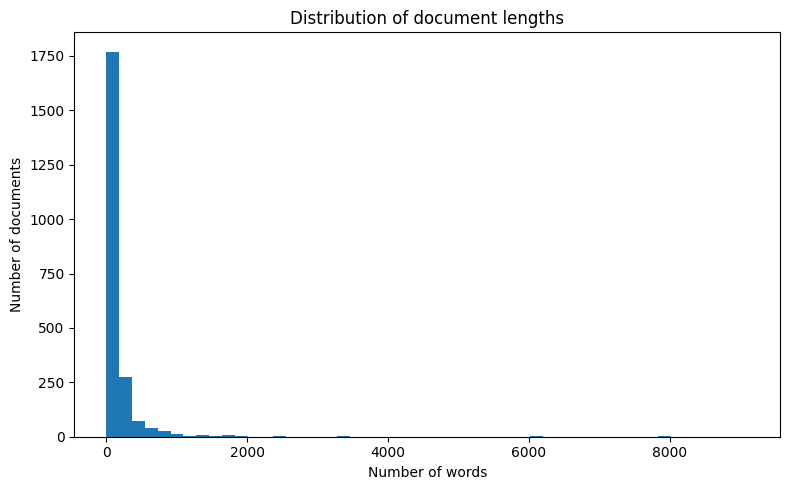

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["word_count"], bins=50)
plt.title("Distribution of document lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.tight_layout()
plt.show()

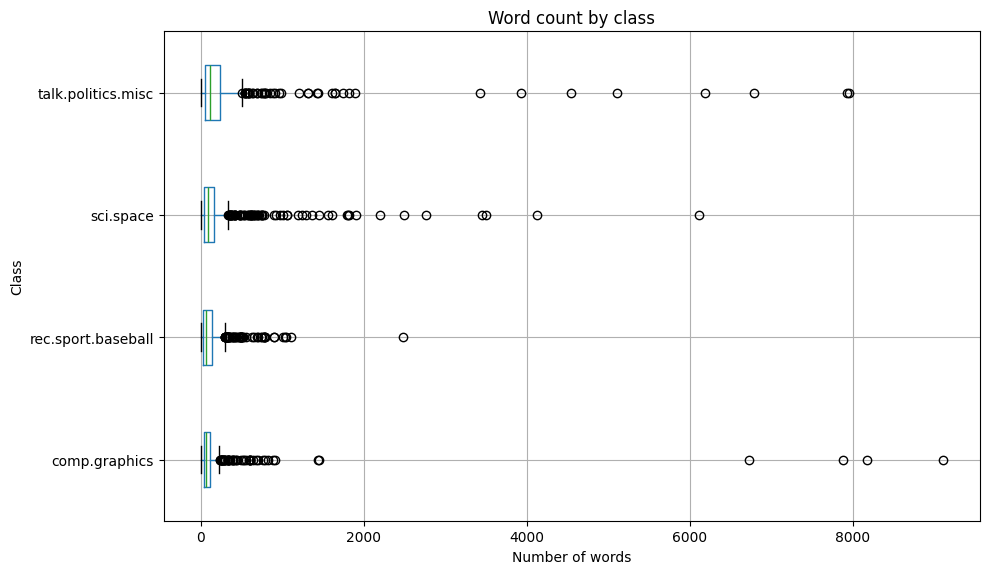

In [12]:
df.boxplot(column="word_count", by="label", vert=False, figsize=(10, 6))
plt.title("Word count by class")
plt.suptitle("")
plt.xlabel("Number of words")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

## 7. Check data quality

Text datasets often contain noise. We check for:

- very short documents
- very long documents
- documents with many non-alphabetic characters


In [13]:
# Very short documents
short_docs = df[df["word_count"] < 10]
print("Number of very short documents:", len(short_docs))
short_docs[["label", "word_count", "text"]].head()

Number of very short documents: 127


,label,word_count,text
0,rec.sport.baseball,6,I thought that was Sandy Koufax.
7,rec.sport.baseball,0,
17,rec.sport.baseball,0,\n
43,comp.graphics,6,I'll contact you offline about this.
74,rec.sport.baseball,0,


In [14]:
# Very long documents
long_docs = df.sort_values("word_count", ascending=False).head(5)
long_docs[["label", "word_count", "text"]]

,label,word_count,text
51,comp.graphics,9109,Archive-name: jpeg-faq\nLast-modified: 18 Apri...
1647,comp.graphics,8176,Archive-name: graphics/resources-list/part3\nL...
2034,talk.politics.misc,7952,SECRET PURPOSE OF FALKLANDS WAR; [with IN-VIS...
1722,talk.politics.misc,7935,THE WHITE HOUSE\n\n Office of...
1889,comp.graphics,7877,Archive-name: graphics/resources-list/part1\nL...


In [15]:
# Find text that is non-alphabetic characters
def non_alpha_ratio(text):
    text = str(text)
    if len(text) == 0:
        return 0

    non_alpha = sum(1 for char in text if not char.isalpha() and not char.isspace())
    return non_alpha / len(text)

df["non_alpha_ratio"] = df["text"].apply(non_alpha_ratio)
df[["label", "non_alpha_ratio", "text"]].sort_values("non_alpha_ratio", ascending=False).head()

,label,non_alpha_ratio,text
671,comp.graphics,1.000000,------------------------------------
380,comp.graphics,0.987342,==============================================...
623,talk.politics.misc,0.908046,\n ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^...
1030,talk.politics.misc,0.650794,==============================================...
1846,comp.graphics,0.648305,-- \n ||||||||||| \t\t \t ||||||||||| \n_|...


## 8. Text cleaning

### Remove noisy text

In [16]:
threshold = 0.2
df_ = df[df["non_alpha_ratio"] <= threshold].copy()

print(f"Number of documents before removing noisy text: {len(df)}")
print(f"Number of documents after removing noisy text: {len(df_)}")

df = df_.copy()

Number of documents before removing noisy text: 2239
Number of documents after removing noisy text: 2122


### Remove empty or duplicate text.

In [17]:
df_ = df.drop_duplicates(subset=["text"])
df_ = df_[df_["text"].astype(str).str.strip().ne("")]

print("Original number of documents:", len(df))
print("Number of documents after removing duplicates and empty texts:", len(df_))

df = df_.copy()

Original number of documents: 2122
Number of documents after removing duplicates and empty texts: 2058


### We can then apply the following:

- Converts text to lowercase
- Removes URLs
- Removes email addresses
- Removes numbers
- Removes punctuation
- Removes extra spaces


In [18]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)                # remove URLs
    text = re.sub(r"\b[\w.-]+@[\w.-]+\.[a-zA-Z]{2,}\b", " ", text)    # remove emails
    text = re.sub(r"\d+", " ", text)                                  # remove numbers
    text = re.sub(rf"[{re.escape(string.punctuation)}]", " ", text)   # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()

,text,clean_text
0,I thought that was Sandy Koufax.,i thought that was sandy koufax
1,"\nAnd the religious right worships engines, sm...",and the religious right worships engines smoke...
2,\nHow can a witness tell that someone in a bur...,how can a witness tell that someone in a burni...
3,"\n\n\n\nYes, long before Star Trek. Before Ei...",yes long before star trek before einstein in f...
4,\n\nIt depends. If you can get your old veter...,it depends if you can get your old veterans ch...


## 9. Tokenization

After cleaning the text, we can process tokenization.

A token is a unit of text, usually a word.

In [19]:
def tokenize(text):
    tokens = str(text).split()
    return tokens

df["tokens"] = df["clean_text"].apply(tokenize)
df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,i thought that was sandy koufax,"[i, thought, that, was, sandy, koufax]"
1,and the religious right worships engines smoke...,"[and, the, religious, right, worships, engines..."
2,how can a witness tell that someone in a burni...,"[how, can, a, witness, tell, that, someone, in..."
3,yes long before star trek before einstein in f...,"[yes, long, before, star, trek, before, einste..."
4,it depends if you can get your old veterans ch...,"[it, depends, if, you, can, get, your, old, ve..."


## 10. Stop word removal

Stop words are very common words such as `the`, `is`, `and`, and `to`. They are often removed when analyzing important content words.


In [20]:
stop_words_df = pd.DataFrame(list(ENGLISH_STOP_WORDS), columns=['Stop words'])
stop_words_df.head(20)

,Stop words
0,hereupon
1,becoming
2,fifteen
3,front
4,meanwhile
5,move
6,fill
7,still
8,very
9,why


In [21]:
stop_words = set(ENGLISH_STOP_WORDS)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

df["clean_tokens"] = df["tokens"].apply(remove_stopwords)
df[["clean_text", "tokens", "clean_tokens"]].head()

,clean_text,tokens,clean_tokens
0,i thought that was sandy koufax,"[i, thought, that, was, sandy, koufax]","[thought, sandy, koufax]"
1,and the religious right worships engines smoke...,"[and, the, religious, right, worships, engines...","[religious, right, worships, engines, smokesta..."
2,how can a witness tell that someone in a burni...,"[how, can, a, witness, tell, that, someone, in...","[witness, tell, burning, truck, dead, unconsci..."
3,yes long before star trek before einstein in f...,"[yes, long, before, star, trek, before, einste...","[yes, long, star, trek, einstein, fact, vulcan..."
4,it depends if you can get your old veterans ch...,"[it, depends, if, you, can, get, your, old, ve...","[depends, old, veterans, cheap, perform, highe..."


In [22]:
all_tokens = [token for tokens in df["tokens"] for token in tokens]

print("Total tokens:", len(all_tokens))
print("Vocabulary size:", len(set(all_tokens)))
print("Average tokens per document:", round(np.mean([len(tokens) for tokens in df["tokens"]]), 2))

# Total number of tokens after stop word removal
all_clean_tokens = [token for tokens in df["clean_tokens"] for token in tokens]

print("\nAfter stop word removal:")
print("Total tokens:", len(all_clean_tokens))
print("Vocabulary size:", len(set(all_clean_tokens)))
print("Average tokens per document:", round(np.mean([len(tokens) for tokens in df["clean_tokens"]]), 2))

Total tokens: 398470
Vocabulary size: 22680
Average tokens per document: 193.62

After stop word removal:
Total tokens: 204631
Vocabulary size: 22377
Average tokens per document: 99.43


## 11. Stemming and lemmatization

After tokenization and stop word removal, we can normalize word forms.

**Stemming** cuts words to a shorter root form. It is fast, but the result may not always be a real word.

**Lemmatization** converts words to their dictionary form, called a lemma. It is usually more readable than stemming, but it can be slower and may require more linguistic information.

Examples:

- `running`, `runs`, `ran` → `run`
- `studies`, `studying` → `study`
- `connections`, `connected` → `connection` or `connect`, depending on the method




In [23]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

sample_words = [
    "running", "runs", "studies", "studying", "connected",
    "connections", "graphics", "computers", "better", "universities"
]

stemming_lemmatization_example = pd.DataFrame({
    "original_word": sample_words,
    "stemmed_word": [stemmer.stem(word) for word in sample_words],
    "lemmatized_word": [lemmatizer.lemmatize(word) for word in sample_words]
})

stemming_lemmatization_example


,original_word,stemmed_word,lemmatized_word
0,running,run,running
1,runs,run,run
2,studies,studi,study
3,studying,studi,studying
4,connected,connect,connected
5,connections,connect,connection
6,graphics,graphic,graphic
7,computers,comput,computer
8,better,better,better
9,universities,univers,university


### Apply stemming and lemmatization to the dataset

We apply both techniques to the cleaned tokens. This allows us to compare how the vocabulary changes after word normalization.



In [24]:
def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

df["stemmed_clean_tokens"] = df["clean_tokens"].apply(stem_tokens)
df["lemmatized_clean_tokens"] = df["clean_tokens"].apply(lemmatize_tokens)

# Show a few examples from one document
sample_index = 2
pd.DataFrame({
    "original_token": df.loc[sample_index, "clean_tokens"][:30],
    "stemmed_token": df.loc[sample_index, "stemmed_clean_tokens"][:30],
    "lemmatized_token": df.loc[sample_index, "lemmatized_clean_tokens"][:30]
})

,original_token,stemmed_token,lemmatized_token
0,witness,wit,witness
1,tell,tell,tell
2,burning,burn,burning
3,truck,truck,truck
4,dead,dead,dead
5,unconscious,unconsci,unconscious
6,kind,kind,kind
7,witnesses,wit,witness
8,talking,talk,talking
9,witnesses,wit,witness


### Compare vocabulary size

Stemming and lemmatization often reduce the vocabulary size because different word forms are grouped together.

For example, `computer` and `computers` may become the same form.



In [25]:
all_stemmed_tokens = [token for tokens in df["stemmed_clean_tokens"] for token in tokens]
all_lemmatized_tokens = [token for tokens in df["lemmatized_clean_tokens"] for token in tokens]

vocab_size = len(set(all_clean_tokens))
stemmed_vocab_size = len(set(all_stemmed_tokens))
lemmatized_vocab_size = len(set(all_lemmatized_tokens))

vocab_comparison = pd.DataFrame({
    "token_version": ["Original tokens", "Stemmed tokens", "Lemmatized tokens"],
    "total_tokens": [len(all_clean_tokens), len(all_stemmed_tokens), len(all_lemmatized_tokens)],
    "vocabulary_size": [vocab_size, stemmed_vocab_size, lemmatized_vocab_size]
})

vocab_comparison


,token_version,total_tokens,vocabulary_size
0,Original tokens,204631,22377
1,Stemmed tokens,204631,15625
2,Lemmatized tokens,204631,20001


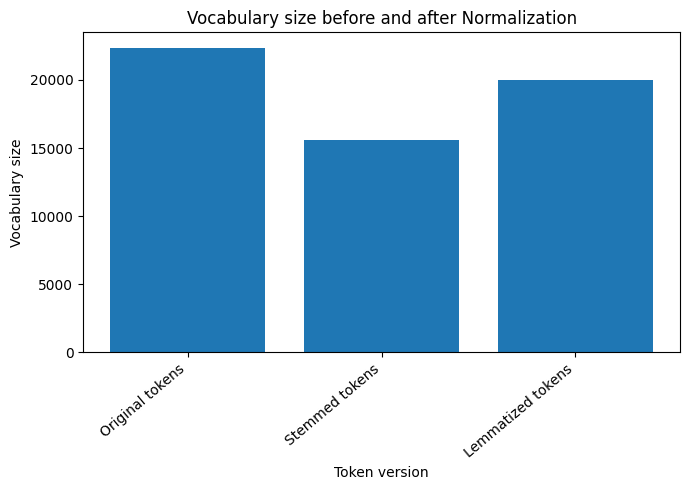

In [26]:
plt.figure(figsize=(7, 5))
plt.bar(vocab_comparison["token_version"], vocab_comparison["vocabulary_size"])
plt.title("Vocabulary size before and after Normalization")
plt.xlabel("Token version")
plt.ylabel("Vocabulary size")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


In [27]:
diff_stemming = vocab_size - stemmed_vocab_size
diff_stemming_percent = (diff_stemming / vocab_size) * 100

diff_lemmatization = vocab_size - lemmatized_vocab_size
diff_lemmatization_percent = diff_lemmatization / vocab_size * 100

print(f"Difference in vocabulary size after stemming: {diff_stemming} ({-diff_stemming_percent:.2f}% reduction)")
print(f"Difference in vocabulary size after lemmatization: {diff_lemmatization} ({-diff_lemmatization_percent:.2f}% reduction)")

Difference in vocabulary size after stemming: 6752 (-30.17% reduction)
Difference in vocabulary size after lemmatization: 2376 (-10.62% reduction)


## 12. Most frequent words

Now we identify the most common words in the dataset after cleaning and stop word removal.


In [28]:
word_freq = Counter(all_clean_tokens)
common_words = pd.DataFrame(word_freq.most_common(20), columns=["word", "count"])
common_words

,word,count
0,s,3140
1,t,2197
2,space,1040
3,don,822
4,think,768
5,people,749
6,like,746
7,just,718
8,d,712
9,know,691


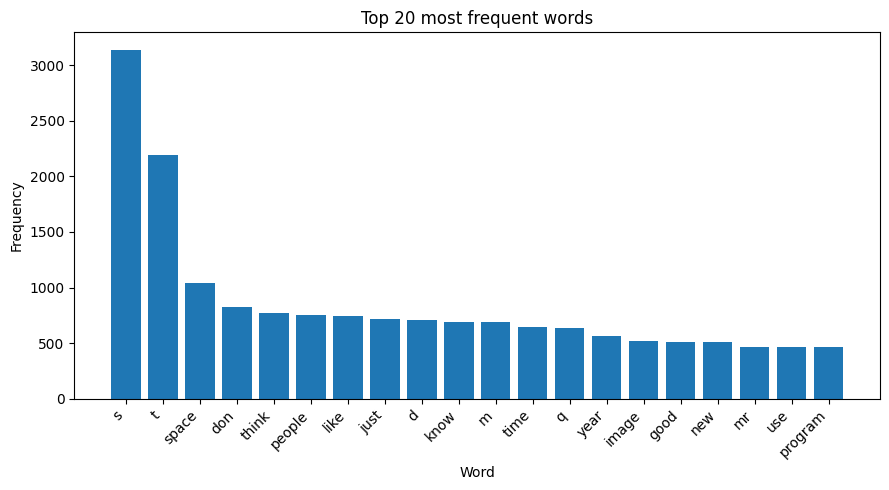

In [29]:
plt.figure(figsize=(9, 5))
plt.bar(common_words["word"], common_words["count"])
plt.title("Top 20 most frequent words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Most frequent words by class

This helps us understand which words are strongly associated with each topic.


In [30]:
def get_top_words_for_label(dataframe, label_name, n=15):
    subset_tokens = [token for tokens in dataframe.loc[dataframe["label"] == label_name, "clean_tokens"] for token in tokens]
    return pd.DataFrame(Counter(subset_tokens).most_common(n), columns=["word", "count"])

for label in df["label"].unique():
    print("\nLabel:", label)
    display(get_top_words_for_label(df, label, n=10))


Label: rec.sport.baseball


,word,count
0,s,661
1,t,537
2,year,290
3,game,201
4,good,196
5,team,188
6,think,183
7,don,175
8,just,155
9,like,149



Label: talk.politics.misc


,word,count
0,s,1264
1,t,832
2,q,574
3,people,498
4,mr,433
5,president,415
6,think,371
7,don,346
8,stephanopoulos,345
9,know,302



Label: sci.space


,word,count
0,space,964
1,s,746
2,t,458
3,nasa,315
4,launch,262
5,m,223
6,like,217
7,earth,214
8,data,205
9,time,194



Label: comp.graphics


,word,count
0,image,483
1,s,469
2,graphics,403
3,t,370
4,d,352
5,x,304
6,jpeg,270
7,file,255
8,data,217
9,files,212


## 14. Word cloud

A word cloud gives a quick visual summary of frequent words.

Larger words appear more frequently.


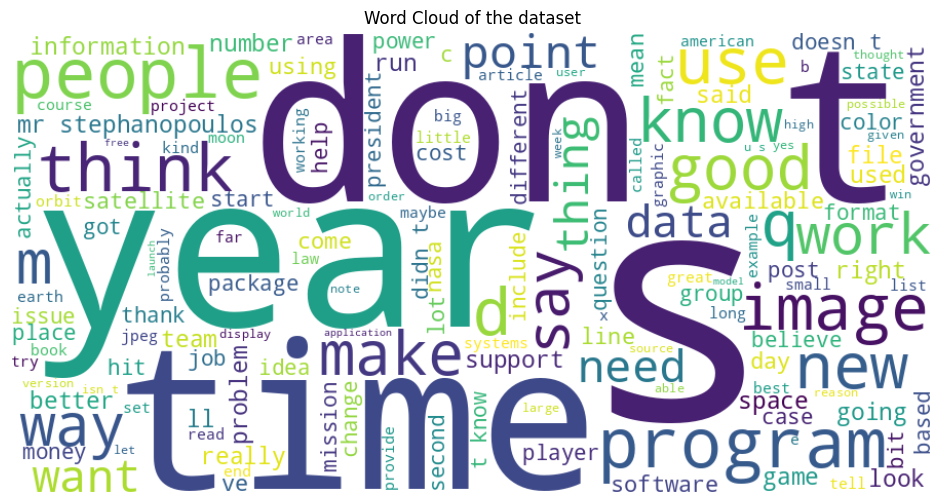

In [31]:
text_for_wordcloud = " ".join(all_clean_tokens)

# This function by default removes stop words using their own dictionary
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=150,
    random_state=42,
).generate(text_for_wordcloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of the dataset")
plt.show()

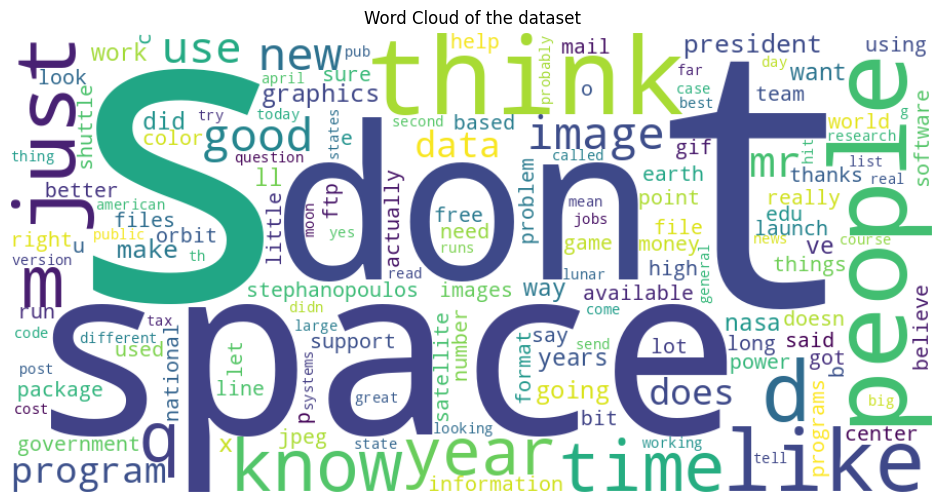

In [32]:
# Show word cloud based on word frequencies
word_frequencies = Counter(all_clean_tokens)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=150,
    random_state=42
).generate_from_frequencies(word_frequencies)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of the dataset")
plt.show()

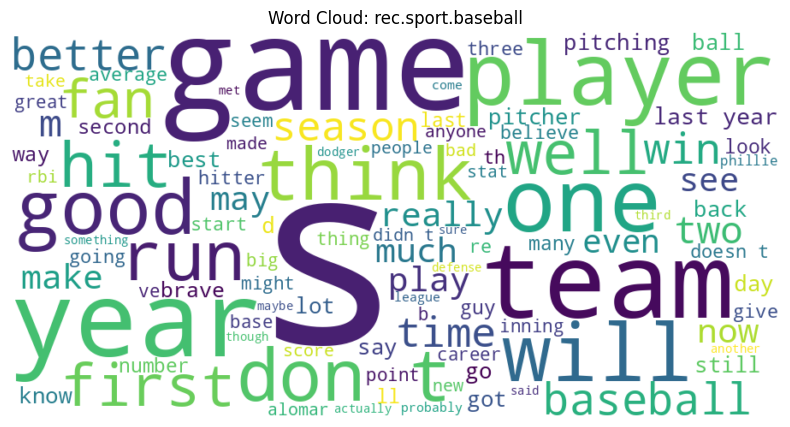

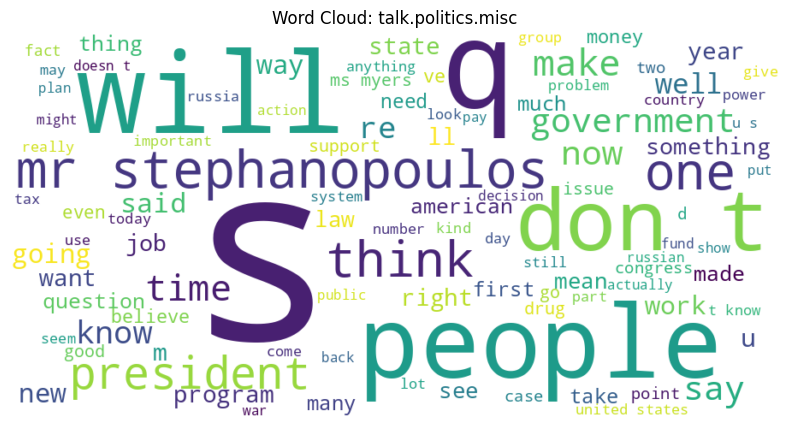

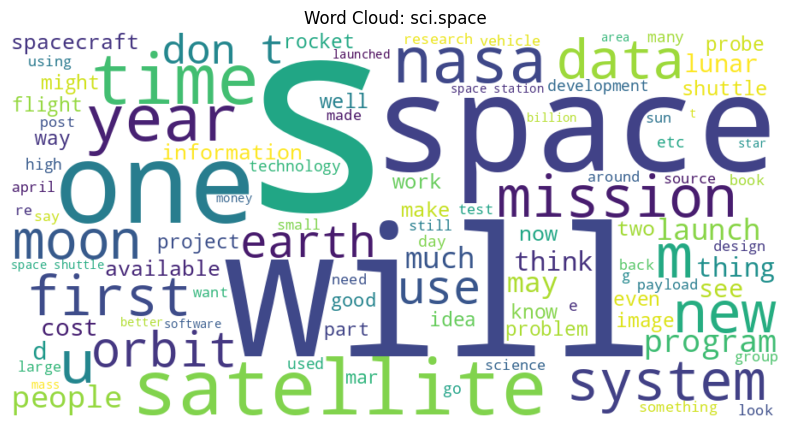

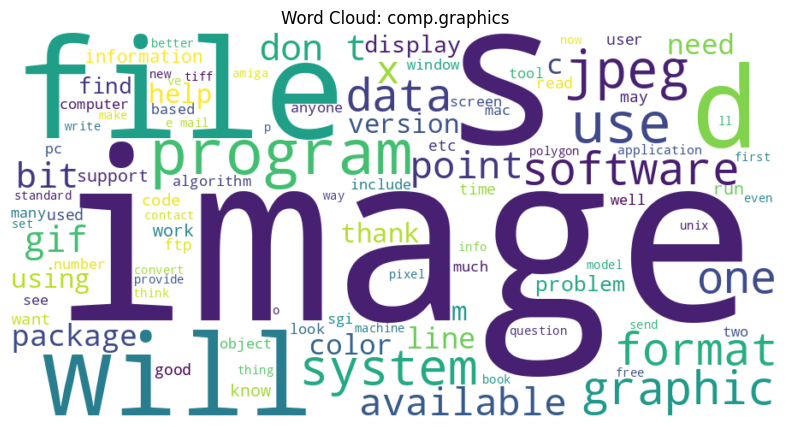

In [33]:
# Word cloud for each class
for label in df["label"].unique():
    label_tokens = [token for tokens in df.loc[df["label"] == label, "tokens"] for token in tokens]
    label_text = " ".join(label_tokens)

    wordcloud = WordCloud(
        width=900,
        height=450,
        background_color="white",
        max_words=100,
        random_state=42,
        relative_scaling=1,
        prefer_horizontal=1,
    ).generate(label_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud: {label}")
    plt.show()

## 15. Rare words

Rare words may be spelling errors, names, technical terms, or noisy tokens.

We can inspect words that appear only once.


In [34]:
rare_words = [word for word, count in word_freq.items() if count == 1]

print("Number of rare words appearing only once:", len(rare_words))

Number of rare words appearing only once: 9624


In [35]:
pd.DataFrame({
    "rare_word_example": rare_words[:30]
})

,rare_word_example
0,worships
1,smokestacks
2,landfills
3,healthily
4,russ
5,repaired
6,hulk
7,alaskan
8,devastated
9,microbial


In [36]:
frequency_table = pd.DataFrame(word_freq.items(), columns=["word", "count"])
frequency_table["frequency_group"] = pd.cut(
    frequency_table["count"],
    bins=[0, 1, 2, 5, 10, 50, 100, np.inf],
    labels=["1", "2", "3-5", "6-10", "11-50", "51-100", ">100"]
)

frequency_table["frequency_group"].value_counts().sort_index()

,count
frequency_group,
1,9624
2,3422
3-5,3745
6-10,2119
11-50,2712
51-100,461
>100,294


## 16. Exercise

1. Load all categories from the 20 Newsgroups dataset.
2. Appy the same exploratory data analysis and preprocessing steps.
3. Compare results and discuss any observed differences.